In [38]:
import pandas as pd
import yfinance as yfin
import matplotlib.pyplot as plt
import datetime as dt
import numpy as np
from scipy import stats

In [39]:
NiftyTicker = ['^NSEI']
RelianceTicker = ['RELIANCE.NS']

# Indicate the start and end dates
start = dt.datetime.now().replace(year=dt.datetime.now().year - 5)
end = dt.datetime.now()

nifty = yfin.download(NiftyTicker, start = start, end = end)
reliance = yfin.download(RelianceTicker, start = start, end = end)

Tickers = [
    'ADANIENT.NS', 'ADANIPORTS.NS', 'APOLLOHOSP.NS', 'ASIANPAINT.NS', 'AXISBANK.NS',
    'BAJAJ-AUTO.NS', 'BAJFINANCE.NS', 'BAJAJFINSV.NS', 'BEL.NS', 'BHARTIARTL.NS',
    'CIPLA.NS', 'COALINDIA.NS', 'DRREDDY.NS', 'EICHERMOT.NS', 'ETERNAL.NS',
    'GRASIM.NS', 'HCLTECH.NS', 'HDFCBANK.NS', 'HDFCLIFE.NS', 'HINDALCO.NS',
    'HINDUNILVR.NS', 'ICICIBANK.NS', 'INDIGO.NS', 'INFY.NS', 'ITC.NS',
    'JIOFIN.NS', 'JSWSTEEL.NS', 'KOTAKBANK.NS', 'LT.NS', 'M&M.NS',
    'MARUTI.NS', 'MAXHEALTH.NS', 'NESTLEIND.NS', 'NTPC.NS', 'ONGC.NS',
    'POWERGRID.NS', 'RELIANCE.NS', 'SBILIFE.NS', 'SHRIRAMFIN.NS', 'SBIN.NS',
    'SUNPHARMA.NS', 'TCS.NS', 'TATACONSUM.NS', 'TMPV.NS', 'TATASTEEL.NS',
    'TECHM.NS', 'TITAN.NS', 'TRENT.NS', 'ULTRACEMCO.NS', 'WIPRO.NS',
]

#Tickers = ['RELIANCE.NS', 'HDFCBANK.NS', 'TCS.NS', 'INFY.NS', 'ITC.NS', 'HEROMOTOCO.NS', 'COALINDIA.NS', 
#          'TATASTEEL.NS', 'BRITANNIA.NS', 'APOLLOHOSP.NS']

stocks = yfin.download(Tickers, start = start, end = end)

stocks.head()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  50 of 50 completed


Price             Close                                                        \
Ticker      ADANIENT.NS ADANIPORTS.NS APOLLOHOSP.NS ASIANPAINT.NS AXISBANK.NS   
Date                                                                            
2021-08-30  1513.172241    710.593323   4693.548340   2964.615234  780.188232   
2021-08-31  1584.063843    728.406860   4902.695801   3052.922363  782.626160   
2021-09-01  1561.713623    724.951172   4971.261230   3149.621094  794.965149   
2021-09-02  1567.051758    733.809326   4975.651367   3148.524414  798.746338   
2021-09-03  1562.063110    734.831421   4947.090820   3183.999512  794.069519   

Price                                                                          \
Ticker     BAJAJ-AUTO.NS BAJAJFINSV.NS BAJFINANCE.NS     BEL.NS BHARTIARTL.NS   
Date                                                                            
2021-08-30   3319.219238   1651.314331    698.744934  57.357895    587.829529   
2021-08-31   3325.865967   1709.981445    733.752869  58.168171    629.137268   
2021-09-01   3353.032715   1673.839722    733.275085  59.165428    631.363708   
2021-09-02   3319.709717   1665.558472    731.212646  59.258919    631.458496   
2021-09-03   3352.318604   1668.659668    733.645752  61.892296    623.831726   

Price       ...       Volume                                               \
Ticker      ... SUNPHARMA.NS TATACONSUM.NS TATASTEEL.NS   TCS.NS TECHM.NS   
Date        ...                                                             
2021-08-30  ...      3617125       1875514    134443870  2033114  2742699   
2021-08-31  ...      7435465       2132008    247521080  3207480  6392991   
2021-09-01  ...      2811619       2051666     88128970  2643336  1829925   
2021-09-02  ...      2679549       1314628     61480460  3403717  3860958   
2021-09-03  ...      2860730       1075187     84523820  1746812  1919590   

Price                                                           
Ticker     TITAN.NS   TMPV.NS TRENT.NS ULTRACEMCO.NS  WIPRO.NS  
Date                                                            
2021-08-30  1670309  17217097  1981330        319952   8743710  
2021-08-31  1816071  36951003   968660        475968  15591816  
2021-09-01  1247432  33103168   861143        352822   9450444  
2021-09-02  1167157  14907001   600794        393057   9077556  
2021-09-03  1548784  16594135   454344        198454   7549940  

[5 rows x 250 columns]

In [40]:
nifty['Returns'] = nifty['Close'].squeeze().pct_change(1) * 100
reliance['Returns'] = reliance['Close'].squeeze().pct_change(1) * 100

riskFreeDailyReturns = 6.5/252   # 6.5% annual, expressed as daily percent

returns = pd.DataFrame({
    'niftyAdjusted':    nifty['Returns'],
    'relianceAdjusted': reliance['Returns'],
}).dropna()

returns = returns - riskFreeDailyReturns

dailyReturns = stocks['Close'].pct_change(1, fill_method=None) * 100

dailyReturns = dailyReturns - riskFreeDailyReturns

print(f"Observations used: {len(returns)}")
returns

Observations used: 1234


,niftyAdjusted,relianceAdjusted
Date,,
2021-08-31,1.162251,-0.558755
2021-09-01,-0.352367,0.370546
2021-09-02,0.898885,1.178385
2021-09-03,0.493229,4.075490
2021-09-06,0.287081,1.527502
...,...,...
2026-08-21,0.057363,0.187430
2026-08-24,-0.161656,-0.496915
2026-08-25,0.451104,0.523905


In [41]:
slope, intercept, r_value, p_value, std_err = stats.linregress(returns['niftyAdjusted'], returns['relianceAdjusted'])

In [42]:
print(f"Beta (slope):        {slope:.4f}")
print(f"Alpha (intercept):   {intercept:.6f}  (daily %)")
print(f"Alpha annualized:    {intercept*252:.4f}  (% per year, approx)")
print(f"R-squared:           {r_value**2:.4f}")
print(f"Correlation r:       {r_value:.4f}")
print(f"P-value (beta != 0): {p_value:.2e}")

Beta (slope):        1.1091
Alpha (intercept):   -0.005283  (daily %)
Alpha annualized:    -1.3312  (% per year, approx)
R-squared:           0.4689
Correlation r:       0.6848
P-value (beta != 0): 1.64e-171


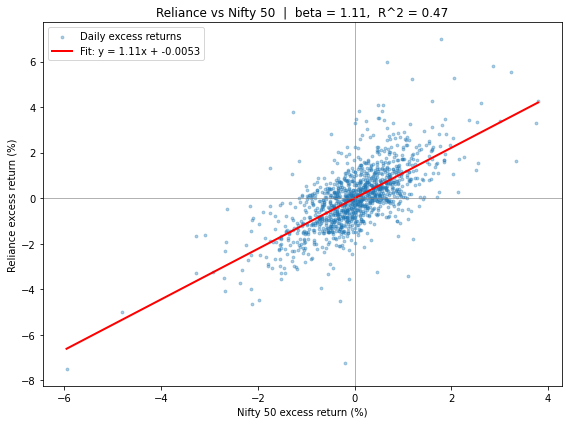

In [43]:
# Scatter of excess returns with the fitted CAPM characteristic line
x = returns['niftyAdjusted']
y = returns['relianceAdjusted']

plt.figure(figsize=(8, 6))
plt.scatter(x, y, s=8, alpha=0.35, label='Daily excess returns')

x_line = np.linspace(x.min(), x.max(), 100)
plt.plot(x_line, intercept + slope * x_line, color='red', linewidth=2,
         label=f'Fit: y = {slope:.2f}x + {intercept:.4f}')

plt.axhline(0, color='grey', linewidth=0.6)
plt.axvline(0, color='grey', linewidth=0.6)
plt.title(f'Reliance vs Nifty 50  |  beta = {slope:.2f},  R^2 = {r_value**2:.2f}')
plt.xlabel('Nifty 50 excess return (%)')
plt.ylabel('Reliance excess return (%)')
plt.legend()
plt.tight_layout()
plt.show()

In [44]:
# Is beta statistically different from 1? (i.e. is Reliance really riskier
# than the market, or is beta ~ 1 within noise?)
# linregress gives std_err of the slope, so we t-test (beta - 1)/std_err.

n = len(returns)
df = n - 2                      # degrees of freedom for a simple regression
t_stat = (slope - 1) / std_err
p_two_sided = 2 * stats.t.sf(abs(t_stat), df)

# 95% confidence interval for beta
t_crit = stats.t.ppf(0.975, df)
ci_low, ci_high = slope - t_crit * std_err, slope + t_crit * std_err

print(f"Beta:                 {slope:.4f}")
print(f"Std error of beta:    {std_err:.4f}")
print(f"95% CI for beta:      [{ci_low:.4f}, {ci_high:.4f}]")
print(f"t-stat (beta = 1):    {t_stat:.3f}")
print(f"p-value (beta != 1):  {p_two_sided:.4f}")
print()
if p_two_sided < 0.05:
    print("=> Beta is significantly different from 1 at the 5% level.")
else:
    print("=> Cannot reject beta = 1: statistically indistinguishable from the market.")

Beta:                 1.1091
Std error of beta:    0.0336
95% CI for beta:      [1.0431, 1.1751]
t-stat (beta = 1):    3.245
p-value (beta != 1):  0.0012

=> Beta is significantly different from 1 at the 5% level.


# Testing CAPM across time — the Security Market Line

The cells above fit a single stock's *characteristic line* (Reliance vs the Nifty). Now we test CAPM in the **cross-section**: for every Nifty 50 stock we estimate its beta and its average excess return, then ask whether average return rises with beta the way CAPM predicts.

In excess-return space the **theoretical SML** is

$$E[R_i] - R_f = \beta_i \,\big(E[R_m] - R_f\big)$$

— a line through the origin whose slope is the market's *own* realized excess return. The **empirical fit** is an OLS regression of realized mean excess returns on betas. The gap between the two lines is the CAPM test.

We run the whole exercise over **5-year and 2-year** look-back windows, because realized-return SML tests turn out to be highly sensitive to the sample window.

### Cleaning the Tata Motors (TMPV) demerger artifact
Tata Motors demerged in late 2025; the passenger-vehicle entity (**TMPV**) dropped sharply on the demerger date, producing a spurious single-day "return" of roughly &minus;60% that is a corporate action, not a market move. We null that day **for TMPV only**. We deliberately do *not* apply a blanket &plusmn;20% outlier filter, because that would also delete genuine crash days (e.g. the Adani names during Jan-2023), which would bias those stocks' betas.

In [45]:
# --- Clean ONLY the Tata Motors (TMPV) demerger-day artifact ---
if 'TMPV.NS' in dailyReturns.columns:
    col = dailyReturns['TMPV.NS']
    artifact_days = col.index[col.abs() > 30]          # ~ -60% demerger day; TMPV has no genuine >30% days
    dailyReturns.loc[artifact_days, 'TMPV.NS'] = np.nan
    print(f"TMPV: nulled {len(artifact_days)} demerger-artifact day(s): "
          f"{[str(d.date()) for d in artifact_days]}")

# Market excess-return series (Nifty) used as the regressor for every stock,
# and the most recent date, from which each look-back window is measured.
niftyExcess = returns['niftyAdjusted']
end_date    = dailyReturns.index.max()
print(f"Data span: {dailyReturns.index.min().date()} -> {end_date.date()}")

TMPV: nulled 1 demerger-artifact day(s): ['2025-10-14']
Data span: 2021-08-30 -> 2026-08-28


In [46]:
# --- Reusable SML machinery ---
def compute_sml(stock_returns, market_returns, years, end_date, min_obs=30):
    """For a given look-back window, estimate beta & mean excess return for each
    stock (regressing its excess return on the market's), then fit the cross-sectional SML."""
    start_date = end_date - pd.DateOffset(years=years)
    m = market_returns[market_returns.index >= start_date]
    rows = []
    for stock in stock_returns.columns:
        pair = pd.concat([m, stock_returns[stock]], axis=1, keys=['mkt', 'stk'], sort=False).dropna()
        if len(pair) < min_obs:                 # skip stocks with too little history in this window
            continue
        reg = stats.linregress(pair['mkt'], pair['stk'])
        rows.append({'stock': stock, 'beta': reg.slope, 'alpha': reg.intercept,
                     'mean': pair['stk'].mean(), 'market_mean': pair['mkt'].mean(),
                     'r_squared': reg.rvalue ** 2, 'n': len(pair)})
    linreg = pd.DataFrame(rows)
    sml = stats.linregress(linreg['beta'], linreg['mean'])   # empirical cross-sectional fit
    mkt_premium = linreg['market_mean'].mean()               # theoretical SML slope
    return linreg, sml, mkt_premium

def plot_sml(linreg, sml, mkt_premium, label):
    x, y = linreg['beta'], linreg['mean']
    plt.figure(figsize=(10, 8))
    plt.scatter(x, y, s=50, alpha=0.9)
    for _, row in linreg.iterrows():
        plt.annotate(row['stock'].replace('.NS', ''), xy=(row['beta'], row['mean']),
                     xytext=(4, 4), textcoords='offset points', fontsize=7)
    b = np.linspace(0, x.max() * 1.05, 100)
    plt.plot(b, sml.intercept + sml.slope * b, color='red', linewidth=2,
             label=f'Empirical: y = {sml.slope:.3f}·β + {sml.intercept:.3f}  '
                   f'(R²={sml.rvalue**2:.2f}, p={sml.pvalue:.2f})')
    plt.plot(b, mkt_premium * b, color='green', linestyle='--', linewidth=2,
             label=f'Theoretical: y = {mkt_premium:.4f}·β')
    plt.scatter([1], [mkt_premium], color='green', marker='*', s=250, zorder=5, label='Market (β = 1)')
    plt.axhline(0, color='grey', linewidth=0.6); plt.axvline(0, color='grey', linewidth=0.6)
    plt.title(f'Security Market Line — {label}')
    plt.xlabel('beta'); plt.ylabel('Mean excess return (%)')
    plt.legend(loc='best', fontsize=9); plt.tight_layout(); plt.show()

## 5-year window

The longest window averages out the most idiosyncratic noise, so the cross-sectional beta&ndash;return relationship should be clearest here. Watch the **sign and slope** of the red empirical line versus the green theoretical one, and whether the intercept is near zero (as CAPM wants).

Two biases that lift the *level* of the whole cloud: **survivorship** (we use *today's* constituents applied backward, so past winners are over-represented) and **equal-weighting** (each stock counts equally, unlike the cap-weighted index).

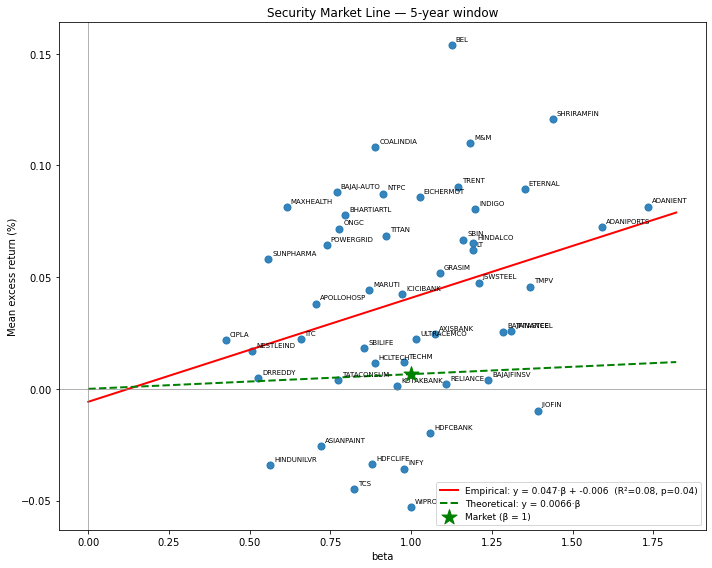

In [47]:
linreg_5y, sml_5y, prem_5y = compute_sml(dailyReturns, niftyExcess, years=5, end_date=end_date)
plot_sml(linreg_5y, sml_5y, prem_5y, '5-year window')

## 2-year window

Shorter window, more noise &mdash; and importantly the **theoretical slope can flip sign**. It equals the market's realized excess return over the window, so if the Nifty underperformed the 6.5% risk-free rate, the green line slopes *down*. Watch whether the empirical line still slopes **up** while the theoretical one turns **negative**: that sign disagreement is a direct contradiction of CAPM (in a market that lagged cash, CAPM predicts high beta should have hurt, not helped).

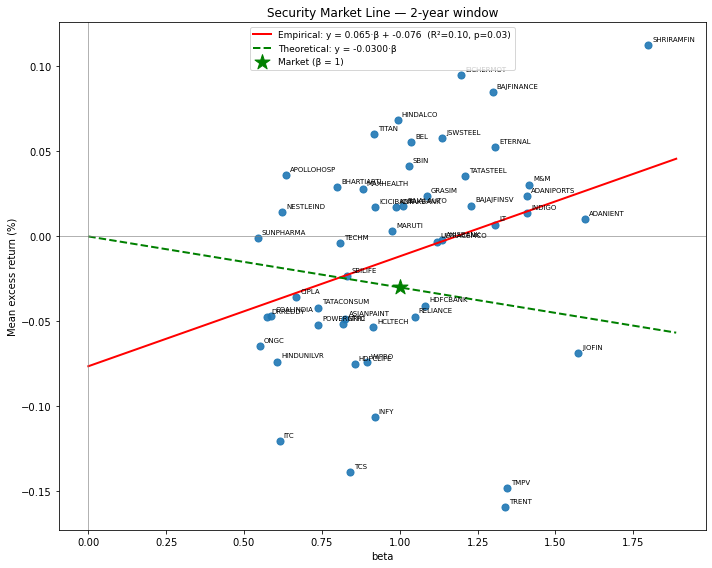

In [48]:
linreg_2y, sml_2y, prem_2y = compute_sml(dailyReturns, niftyExcess, years=2, end_date=end_date)
plot_sml(linreg_2y, sml_2y, prem_2y, '2-year window')

## Comparison across windows

The table below reports, for each window, the **theoretical** SML slope (the market's realized excess return) and the **empirical** fit (slope, intercept, R&sup2;, p-value). The overlay plots all three empirical lines (solid) against their theoretical counterparts (dashed), and the printed lines state, for each window, whether the empirical and theoretical slopes even *agree in sign*.

window  theo_slope (mkt prem, %/day)  theo_slope (%/yr)  emp_slope  emp_intercept   emp_R2    emp_p  n_stocks
2-year                     -0.029995          -7.558729   0.064673      -0.076369 0.097108 0.027599        50
5-year                      0.006588           1.660273   0.046500      -0.005769 0.081227 0.044843        50

Sign check (does the realized SML match CAPM's prediction for the window?):
  2-year: market premium -7.6%/yr (theory slopes down); empirical slope +0.065 (up), significant (p=0.03)  ->  signs *** DISAGREE ***
  5-year: market premium +1.7%/yr (theory slopes up); empirical slope +0.047 (up), significant (p=0.04)  ->  signs AGREE


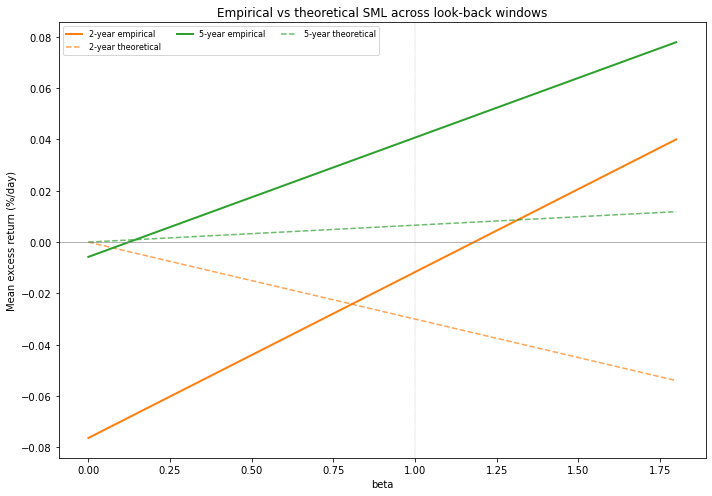

In [49]:
windows = [('2-year', linreg_2y, sml_2y, prem_2y),
           ('5-year', linreg_5y, sml_5y, prem_5y)]

summary = pd.DataFrame([{
    'window': w,
    'theo_slope (mkt prem, %/day)': prem,
    'theo_slope (%/yr)': prem * 252,
    'emp_slope': s.slope,
    'emp_intercept': s.intercept,
    'emp_R2': s.rvalue ** 2,
    'emp_p': s.pvalue,
    'n_stocks': len(lr),
} for (w, lr, s, prem) in windows])
print(summary.to_string(index=False))

# Dynamic, run-accurate interpretation
print("\nSign check (does the realized SML match CAPM's prediction for the window?):")
for (w, lr, s, prem) in windows:
    theo_dir = 'up' if prem > 0 else 'down'
    emp_dir  = 'up' if s.slope > 0 else 'down'
    agree = 'AGREE' if (prem > 0) == (s.slope > 0) else '*** DISAGREE ***'
    sig = 'significant' if s.pvalue < 0.05 else ('marginal' if s.pvalue < 0.10 else 'not significant')
    print(f"  {w}: market premium {prem*252:+.1f}%/yr (theory slopes {theo_dir}); "
          f"empirical slope {s.slope:+.3f} ({emp_dir}), {sig} (p={s.pvalue:.2f})  ->  signs {agree}")

# Overlay of all windows
colors = {'2-year': 'tab:orange', '5-year': 'tab:green'}
b = np.linspace(0, 1.8, 100)
plt.figure(figsize=(10, 7))
for (w, lr, s, prem) in windows:
    plt.plot(b, s.intercept + s.slope * b, color=colors[w], linewidth=2, label=f'{w} empirical')
    plt.plot(b, prem * b, color=colors[w], linestyle='--', linewidth=1.5, alpha=0.7, label=f'{w} theoretical')
plt.axhline(0, color='grey', linewidth=0.6)
plt.axvline(1, color='grey', linewidth=0.4, linestyle=':')
plt.title('Empirical vs theoretical SML across look-back windows')
plt.xlabel('beta'); plt.ylabel('Mean excess return (%/day)')
plt.legend(fontsize=8, ncol=3); plt.tight_layout(); plt.show()

## What the two windows tell us

Read the sign-check lines and the overlay together. The recurring pattern in this exercise:

- **The theoretical SML is not a stable line.** Its slope is just the market's realized excess return over the chosen window, so it swings with the sample &mdash; it can even go *negative* when the Nifty underperforms the risk-free rate (a period when equities lagged cash). CAPM is a statement about **expected** returns; a single window's **realized** market return is a noisy, period-specific stand-in.

- **The empirical slope tends to stay positive but its magnitude is unstable**, and it can *disagree in sign* with the theoretical line in shorter windows. When the empirical line slopes up while the theoretical one slopes down, high-beta stocks were rewarded in a market that itself lost to cash &mdash; the opposite of what CAPM predicts.

- **The shorter window is noisier:** R&sup2; falls and the p-value weakens going from the 5-year to the 2-year window.

### Caveats that apply to every window
1. **Survivorship bias** &mdash; using *today's* Nifty 50 membership backward over-represents past winners and inflates both the level and the slope. A clean test uses point-in-time constituents.
2. **Equal- vs cap-weighting** &mdash; the cross-section equal-weights all names, so it captures outperformance the cap-weighted index never delivered.
3. **Errors-in-variables** &mdash; single-stock betas are measured with error, which *attenuates* the cross-sectional slope toward zero. The classic fix (Black-Jensen-Scholes / Fama-MacBeth) sorts stocks into **beta-ranked portfolios** and estimates betas on a **prior** window, separate from the return-measurement window.

### Bottom line
Across the 2- and 5-year windows the SML is neither stable nor a clean confirmation of CAPM. Beta is *loosely* priced in the right direction over long windows, but realized-return SML tests are dominated by the sample period, by how the universe is weighted, and by which names happen to be in the index today. This is exactly why CAPM is tested on long samples, with point-in-time universes and beta-sorted portfolios &mdash; not a single cross-section of current constituents.